## Description

After EDA, we need to preprocess our data, train some models, and evaluate them. 

Structure of this notebook:

1. Import libraries
2. Load data
3. Train-test split
4. Data preprocessing pipeline
5. Creating an evaluation function
6. Model training and evaluation
7. Feature importance
8. Save models

## Import libraries

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor
import joblib
import matplotlib.pyplot as plt

plt.close("all")
plt.style.use('ggplot')

In [2]:
SEED = 11

## Load data

In [3]:
df = pd.read_csv('data/cleaned.csv')

In [4]:
df.head()

,rooms,size,reconstructed,garage,balcony,new,location,price
0,2.0,58.0,0,0,0,1,Košice,275000.0
1,3.0,130.0,1,0,1,1,Senica,140000.0
2,3.0,66.0,1,0,1,1,Bánovce nad Bebravou,108500.0
3,3.0,84.0,1,0,1,1,Nitra,183000.0
4,2.0,54.0,0,0,1,1,Prešov,179000.0


## Train test split

In [5]:
X = df[['rooms', 'size', 'reconstructed', 'garage', 'balcony', 'new', 'location']]  
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

## Preprocessing pipeline

Based on the EDA results, we need to create a data preprocessing pipeline. It includes preprocessing of the numerical features rooms and size using StandardScaler. For the categorical feature location, we need to apply OneHotEncoder. For the other features - reconstructed, garage, balcony, and new - no additional preprocessing is required because they are binary features with two possible values: 0 and 1.

In [6]:
numerical_features = ['rooms', 'size']
categorical_feature = ['location']

In [7]:
def get_pipeline(model):

    column_transformer = ColumnTransformer( transformers=[
        ('scaler', StandardScaler(), numerical_features),
        ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_feature)
    ], remainder='passthrough')

    model_pipeline = Pipeline( steps=[
        ('preprocessing', column_transformer),
        ('model', model)
    ])

    return model_pipeline

## Evaluation function

For evaluation, we are going to use metrics such as MSE, MAE, MAPE, and R² on the test data. Additionally, we will evaluate our models using cross-validation based on the MAE and MAPE metrics.

In [8]:
def evaluate_model(model, X_test, y_test, model_cv, X, y):

    y_pred = model.predict(X_test)

    print('Metrics on the test data: \n')

    print(f"MSE: {mean_squared_error(y_test, y_pred)}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
    print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")
    print(f"R2: {r2_score(y_test, y_pred)}\n\n")

    print('Cross-validation: \n')


    model_cv_pipeline = get_pipeline(model_cv)
    scores = cross_validate(model_cv_pipeline, X, y, cv=5, scoring=["neg_mean_absolute_error", "neg_mean_absolute_percentage_error"])
    
    for item in list(scores.items())[2:]:

        values = -1 * item[1]

        print(f"Metric: {item[0].replace('test_neg_', '')}")
        print(f'Values: {values}')
        print(f'Mean: {values.mean()}')
        print(f'Standart deviation: {values.std()}\n')


## Linear regression

First, we need to train a simple model such as Linear Regression in order to compare it with more complex models.

In [9]:
lr = LinearRegression()
lr_pipeline= get_pipeline(lr)

In [10]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('ohe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [11]:
y_pred = lr_pipeline.predict(X_test)

print('Metrics on the test data: \n')

print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred)}")
print(f"R2: {r2_score(y_test, y_pred)}\n\n")

Metrics on the test data: 

MSE: 4689026603.536807
MAE: 41609.60996049727
MAPE: 0.2603472013593627
R2: 0.5635109139719127




We can see that Linear Regression achieved MSE = 4,689,026,603.54, MAE = 41,609.61, and MAPE = 26.03%. This means that on average the predictions differ from the real house prices by about 41k, which indicates relatively high prediction error. The R² = 0.5635 shows that the model explains about 56% of the variance, which is moderate performance and suggests that a simple linear relationship is not sufficient to fully capture the structure of the data.

## Random forest

In [12]:
rf = RandomForestRegressor(random_state=SEED)
rf_pipeline = get_pipeline(rf)

param_grid_rf = [{
    'model__n_estimators': [150],
    'model__max_depth': [None, 3, 5, 9],
    'model__min_samples_leaf': [1, 3, 5, 10]
}]

rf_pipeline_gs = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [13]:
rf_pipeline_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=11))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__max_depth': [None, 3, ...], 'model__min_samples_leaf': [1, 3, ...], 'model__n_estimators': [150]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [14]:
rf_pipeline_gs.best_params_

{'model__max_depth': None,
 'model__min_samples_leaf': 1,
 'model__n_estimators': 150}

In [15]:
rf_best = rf_pipeline_gs.best_estimator_

In [16]:
best_params_rf = dict( list( map(lambda x: (x[0].replace('model__', ''), x[1]), rf_pipeline_gs.best_params_.items()) ) )
rf_cv = RandomForestRegressor(random_state=SEED, **best_params_rf)

evaluate_model(rf_best, X_test, y_test, rf_cv, X, y)

Metrics on the test data: 

MSE: 3832377366.8732347
MAE: 34845.71020887972
MAPE: 0.21773797960880864
R2: 0.6432541259374633


Cross-validation: 

Metric: mean_absolute_error
Values: [35839.00854067 32834.68307314 32265.56964206 33620.63631649
 32992.73454801]
Mean: 33510.526424074546
Standart deviation: 1241.671712387043

Metric: mean_absolute_percentage_error
Values: [0.22591096 0.22543614 0.21062129 0.21151023 0.20864863]
Mean: 0.21642545043751818
Standart deviation: 0.007609128230701522



We can see that Random Forest significantly improves the results with MSE = 3,832,377,366.87, MAE = 34,845.71, and MAPE = 21.77%. The average prediction error decreases to about 35k, which is a clear improvement compared to Linear Regression. The R² = 0.6433 indicates that the model explains 64% of the variance, showing that ensemble tree methods capture nonlinear relationships in the data more effectively. Cross-validation results (MAE ≈ 33.5k ± 1.2k) also show stable performance across different data splits.

## XGBoost

In [17]:
xgboost = XGBRegressor(random_state=SEED)
xgboost_pipeline = get_pipeline(xgboost)

param_grid_xgboost = [{
    'model__learning_rate': [0.001, 0.01, 0.1, 0.05],
    'model__n_estimators': [50, 100, 200, 300],
    'model__subsample': [1.0, 0.8],
    'model__max_depth': [2, 3, 4, 7]
}]

xgboost_pipeline_gs = GridSearchCV(xgboost_pipeline, param_grid_xgboost, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

In [18]:
xgboost_pipeline_gs.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__learning_rate': [0.001, 0.01, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [50, 100, ...], 'model__subsample': [1.0, 0.8]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [19]:
xgboost_pipeline_gs.best_params_

{'model__learning_rate': 0.1,
 'model__max_depth': 4,
 'model__n_estimators': 300,
 'model__subsample': 0.8}

In [20]:
xgboost_best = xgboost_pipeline_gs.best_estimator_

In [21]:
best_params_xgboost = dict( list( map(lambda x: (x[0].replace('model__', ''), x[1]), xgboost_pipeline_gs.best_params_.items()) ) )
xgboost_cv = XGBRegressor(random_state=SEED, **best_params_xgboost)

evaluate_model(xgboost_best, X_test, y_test, xgboost_cv, X, y)

Metrics on the test data: 

MSE: 3697702720.661482
MAE: 34983.81752871226
MAPE: 0.21805645476235166
R2: 0.6557906325957503


Cross-validation: 

Metric: mean_absolute_error
Values: [35716.98741065 33506.04351154 31950.72565531 32697.77103882
 34340.30140991]
Mean: 33642.36580524668
Standart deviation: 1308.7137464915907

Metric: mean_absolute_percentage_error
Values: [0.22383641 0.22863379 0.20416257 0.20684436 0.21508   ]
Mean: 0.21571142509312297
Standart deviation: 0.009438247600777931



We can see that XGBoost achieved MSE = 3,697,702,720.66, MAE = 34,983.82, and MAPE = 21.81%, which are very close to the results obtained with Random Forest. The average prediction error remains around 35k, indicating a similar level of accuracy. The R² = 0.6558 is slightly higher than Random Forest, meaning the model explains about 66% of the variance, but the improvement is relatively small. Cross-validation results (MAE ≈ 33.6k ± 1.3k) also show stable performance, suggesting that XGBoost performs similarly to Random Forest. 

## Feature importance

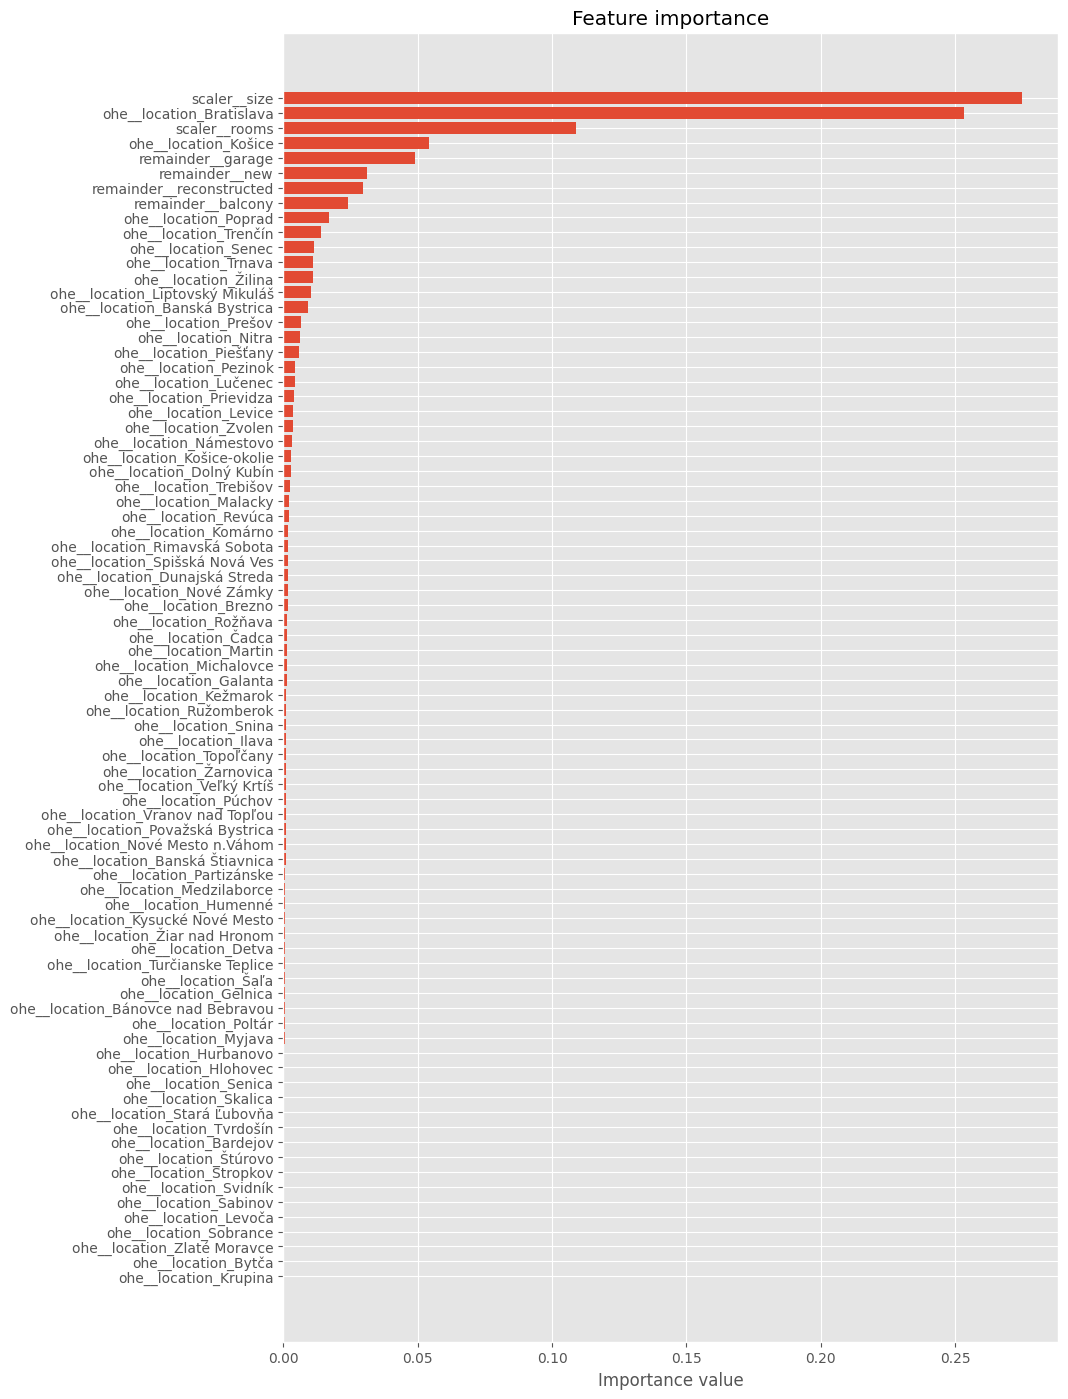

In [ ]:
feature_names = rf_best.named_steps['preprocessing'].get_feature_names_out()
importances = rf_best.named_steps.model.feature_importances_

importances_series = pd.Series(importances, index=feature_names)
importances_series.sort_values(inplace=True, ascending=True)


plt.figure( figsize=(10, 17) )
plt.barh(importances_series.index, importances_series.values)
plt.xlabel('Importance value')
plt.title('Feature importance')
plt.show()

We can see that the attributes with the greatest impact on the prediction are size and location_Bratislava. This is logical because larger apartments are usually more expensive, and Bratislava, being the capital of Slovakia, generally has higher real estate prices. The features rooms, location_Kosice, and garage also have a moderately strong influence on the prediction. During the analysis, we observed a correlation between the attributes rooms and garage and the target feature price. Regarding the location_Kosice attribute, this can be explained by the fact that Kosice is the second-largest city in Slovakia, where apartment prices are significantly higher than in smaller cities. Additionally, attributes such as new, reconstructed, balcony, location_Poprad, and several other city-related features also have some influence on the prediction results, although to a lesser extent. Other city attributes have only a minor impact on the prediction.

## Save models

In [37]:
joblib.dump(lr_pipeline, 'models/linear_regression.joblib')
joblib.dump(rf_best, 'models/random_forest.joblib')
joblib.dump(xgboost_best, 'models/xgboost.joblib')

['models/xgboost.joblib']